## Датасет

winequality-white.csv и winequality-red.csv

Содержат следующие характеристики:
- fixed acidity	- фиксированная кислотность
- volatile acidity	- летучая кислотность
- citric acid	- лимонная кислота
- residual sugar	- остаточный сахар
- chlorides	- хлориды
- free sulfur dioxide - свободный диоксид серы
- total sulfur dioxide	- общий диоксид серы
- density	- density
- pH	- кислотность
- sulphates - сульфаты
- alcohol	- крепость
- quality - качество


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

### Задание 1. Очистка данных (1 балл)
1. Загрузите данные из обоих файлов (красное и белое вино). Добавьте столбец type (0 – красное, 1 – белое) в датафреймы.  Объедините их в один датафрейм
2. Вывести общую информацию (info(), describe()).
3. Определите количество выбросов в числовых столбцах через 1.5 IQR (выбросы оставляем без изменений, просто оцениваем их количество).
4. Постройте гистограммы для всех числовых признаков (можно использовать df.hist(bins=30, figsize=(15,10))).

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  Type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB
Количество выбросов Fixed Acidity: 357
Количество выбросов Volatile Acidity: 3

array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

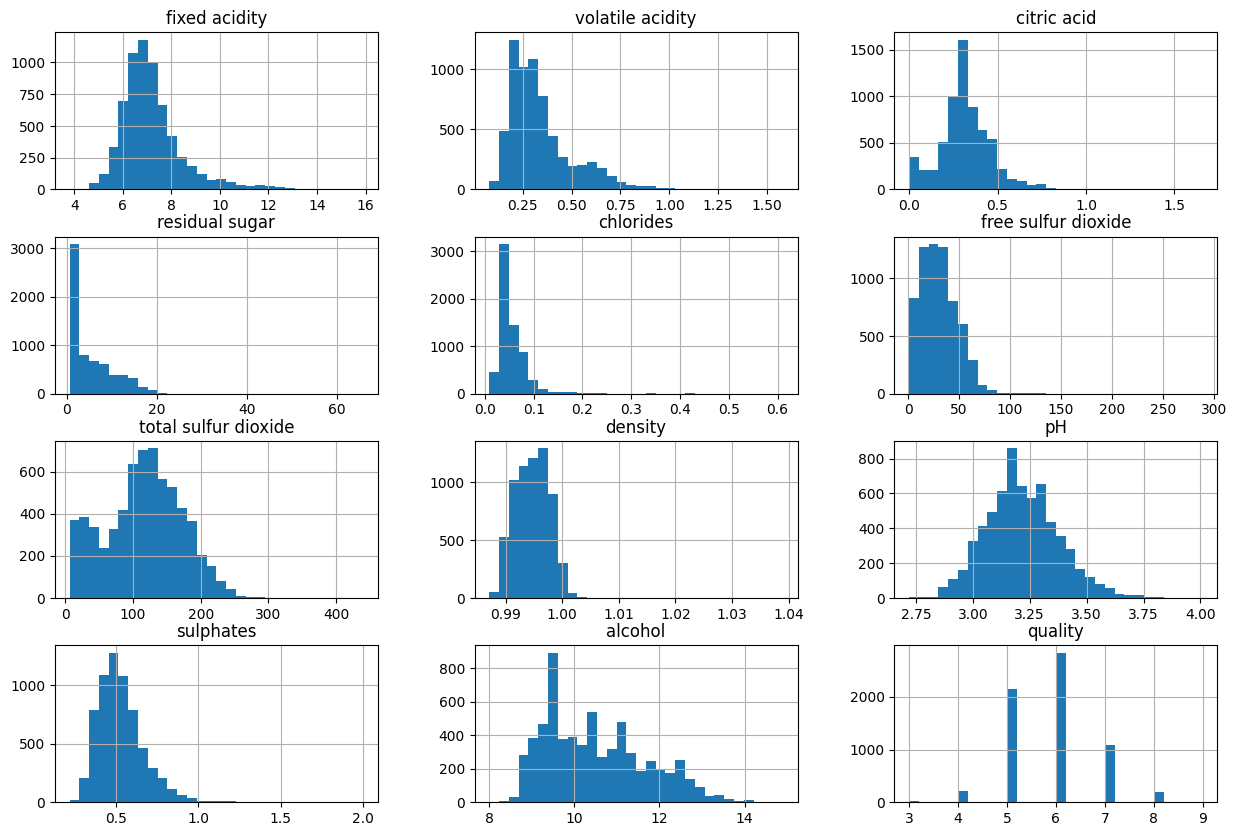

In [ ]:
# your code here
red_wine_data = pd.read_csv(r"D:\Repos\Data_analysis_with_Python\winequality-red.csv",sep = ";")
white_wine_data = pd.read_csv(r"D:\Repos\Data_analysis_with_Python\winequality-white.csv",sep = ";")

red_wine_data["Type"] = "red"
white_wine_data["Type"] = "white"

rw_data = pd.concat([red_wine_data,white_wine_data], ignore_index=True)

rw_data.info()
rw_data.describe()
# print(rw_data)


def find_outliersIQR(data):    
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    mask1 = ((q1 - 1.5 * iqr) > data) 
    mask2 = data > q3 + 1.5 * iqr
    return (mask1 | mask2)
sum_outliners = 0
numeric_cols = rw_data.select_dtypes(include=[np.number]).columns
for column in numeric_cols:
    count_outliners = rw_data[column][find_outliersIQR(rw_data[column])].count()
    print(f"Количество выбросов {column.title()}: {count_outliners}" )
    sum_outliners += count_outliners
print(f"Общее количество выбросов: {sum_outliners}")

rw_data.hist(bins=30, figsize=(15,10))

### Задание 2. Проверка нормальности распределения (1 балл)

Для всех числовых столбцов (кроме `quality` и `type`):
1. Построить гистограмму с кривой нормального распределения (среднее и стандартное отклонение по данным).
2. Вычислить асимметрию (skewness) и эксцесс (kurtosis).
3. Провести тест Шапиро-Уилка.
4. Сделать вывод: распределение нормальное, околонормальное или ненормальное
    - |skewness| < 2 и |excess kurtosis| < 2 – околонормальное
    - дополнительно к предыдущему, p-value > 0.05 – строго нормальное
    - иначе – ненормальное.

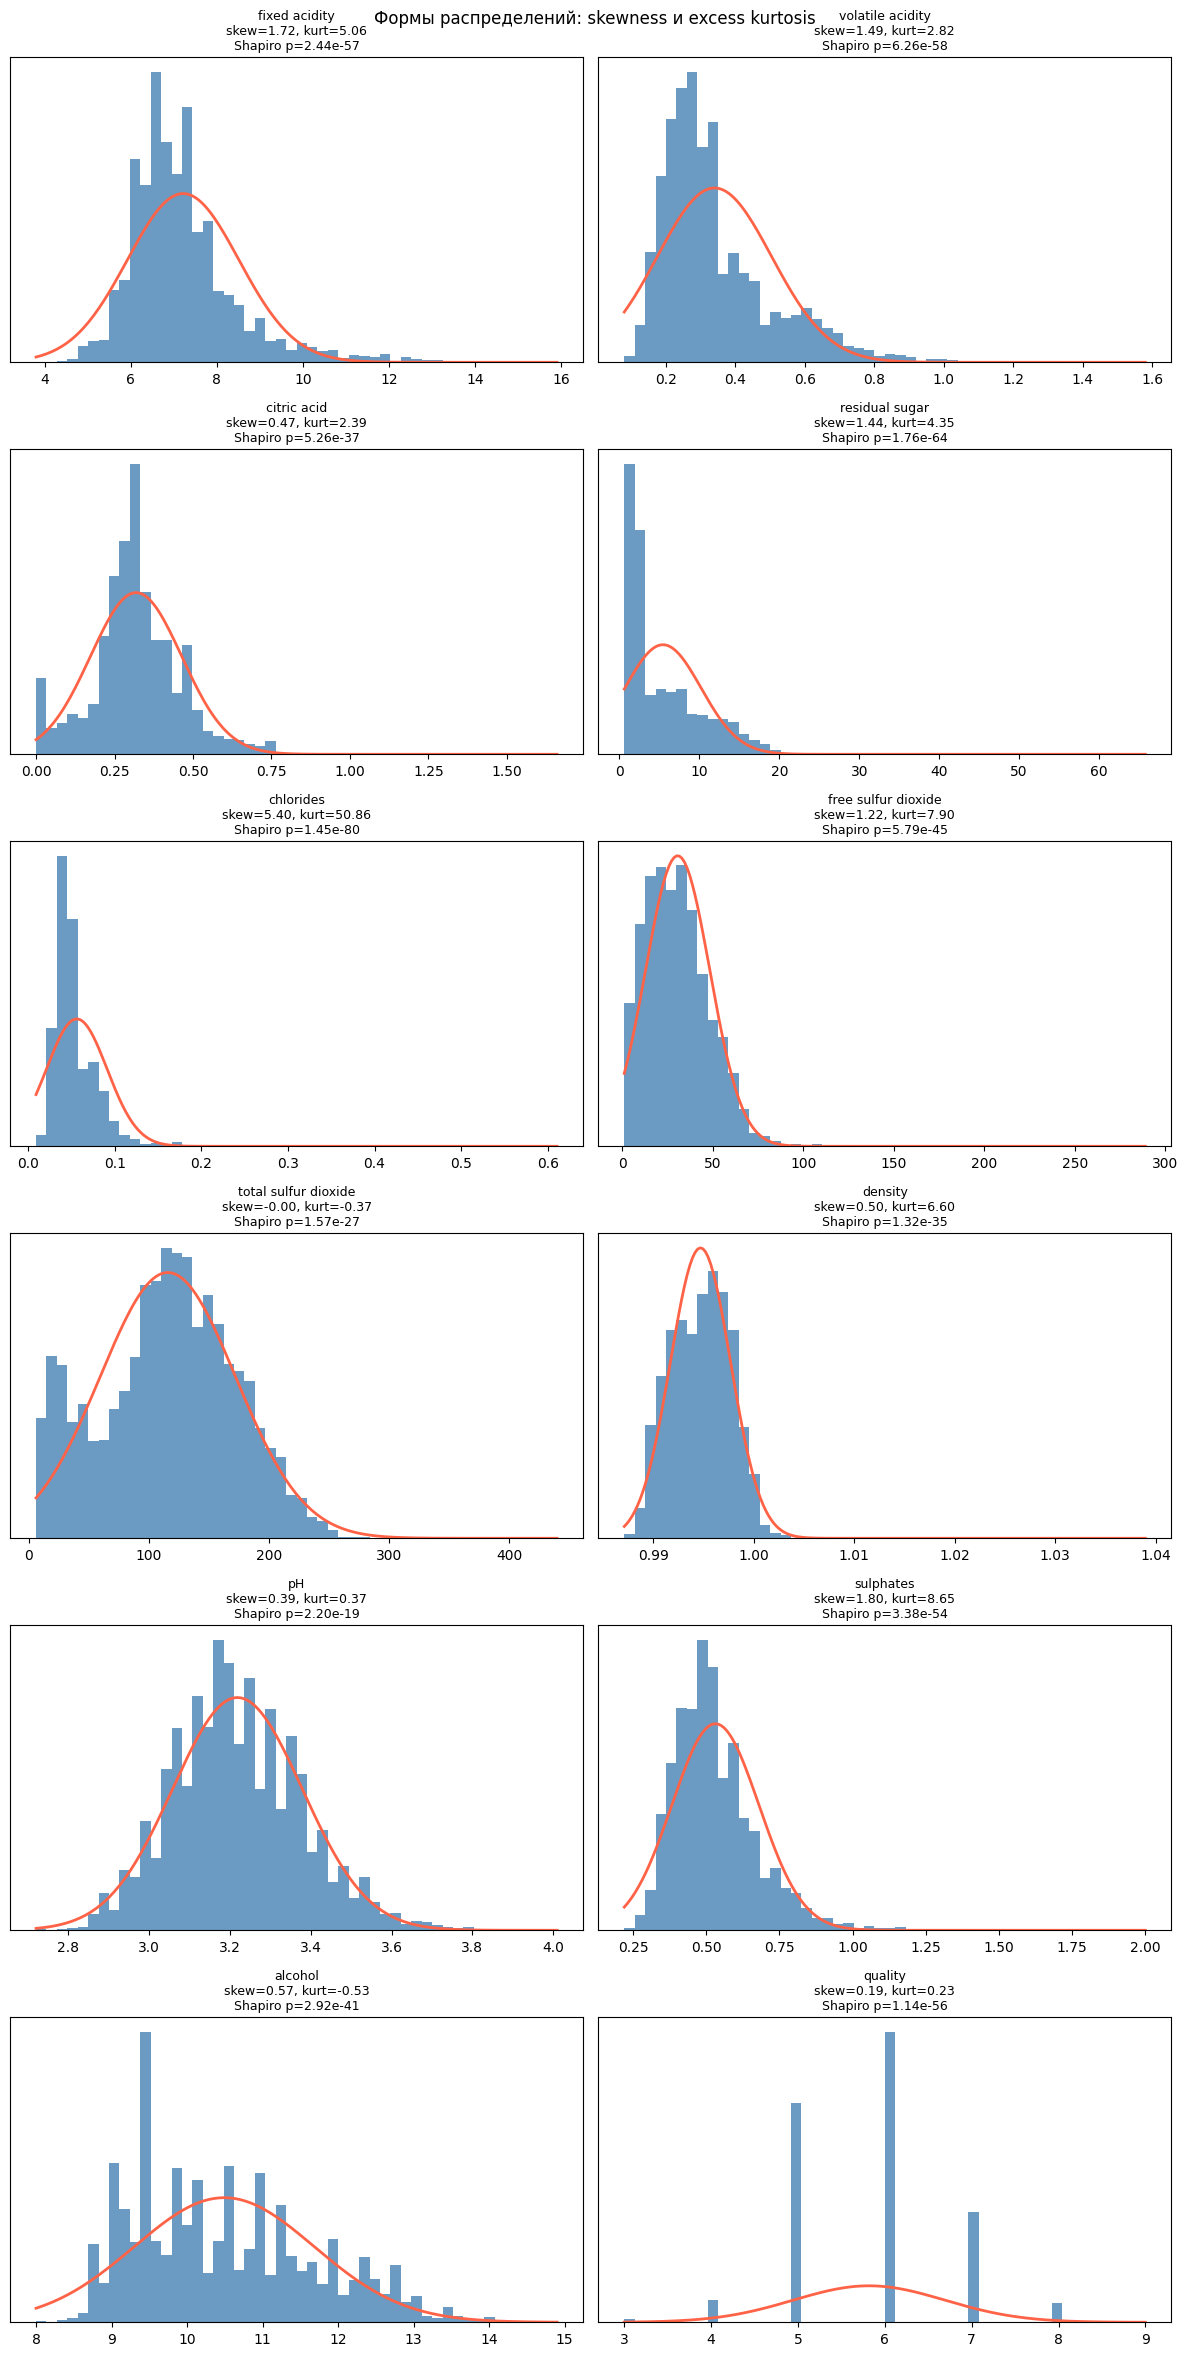

In [32]:
n_cols = len(numeric_cols)
n_rows = (n_cols + 1) // 2  # округление вверх

fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))
axes = axes.flatten()  # сделать плоским для удобного перебора

for i, col in enumerate(numeric_cols):
    data = rw_data[col].dropna()
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)
    stat, p = stats.shapiro(data)                     # тест Шапиро–Уилка
    ax = axes[i]
    ax.hist(data, bins=50, color='steelblue', alpha=0.8, edgecolor='none', density=True)
    xx = np.linspace(data.min(), data.max(), 200)
    ax.plot(xx, stats.norm.pdf(xx, data.mean(), data.std()),
            'tomato', linewidth=2, label='норм.')
    ax.set_title(f"{col}\nskew={skew:.2f}, kurt={kurt:.2f}\nShapiro p={p:.2e}", fontsize=9)
    ax.set_yticks([])

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Формы распределений: skewness и excess kurtosis', fontsize=12)
plt.tight_layout()
plt.show()

### Задание 3. Корреляционный анализ (2 балла)
1. Вычислите матрицы корреляции Пирсона и Спирмена для всех числовых признаков (включая `quality`).
2. Постройте тепловые карты (`seaborn.heatmap`) с аннотацией значений (округление до десятых, `annot=True, fmt='.1f'`).
3. Вывести топ-5 признаков, наиболее сильно коррелирующих с `quality` (по модулю) для каждого метода.
4. Объясните различия между корреляциями Пирсона и Спирмена (оставьте комментарий): почему некоторые коэффициенты различаются? Приведите возможные причины

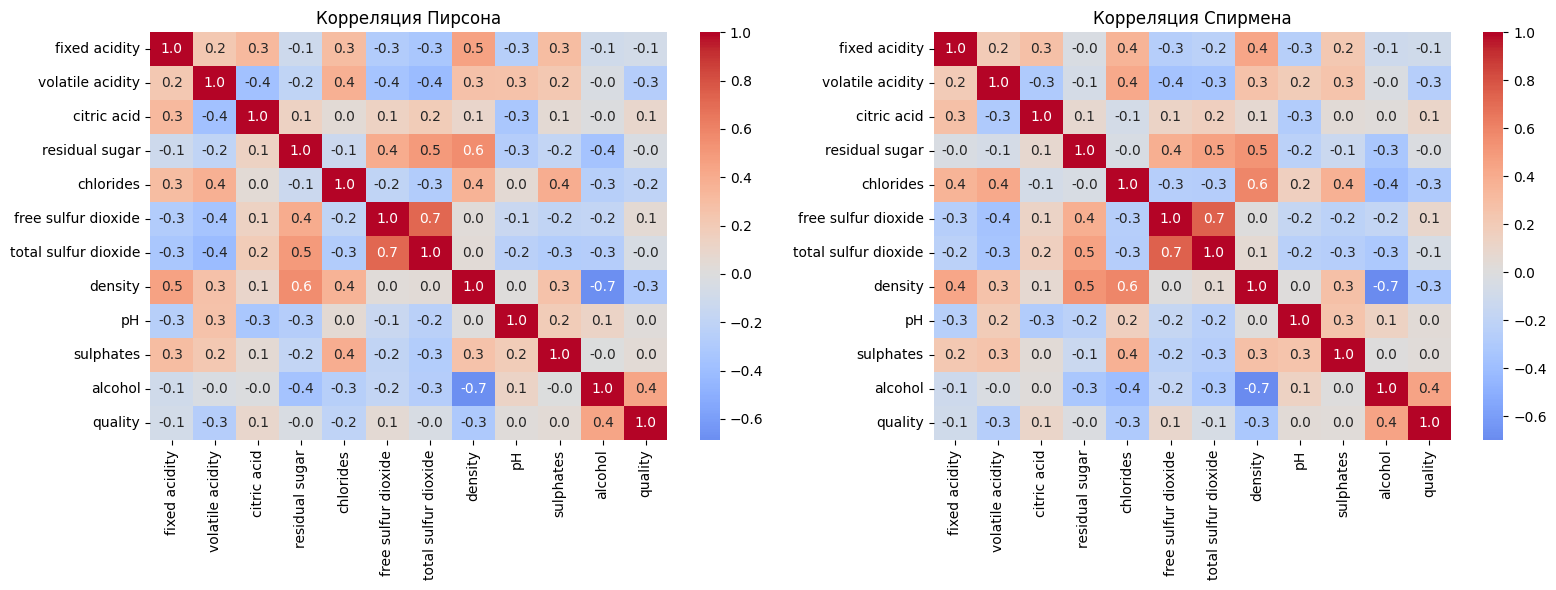


Спирмен – топ-5 корреляций с quality:
   alcohol: 0.447
   density: 0.323
   chlorides: 0.295
   volatile acidity: 0.258
   citric acid: 0.106

Пирсон – топ-5 корреляций с quality:
   alcohol: 0.444
   density: 0.306
   volatile acidity: 0.266
   chlorides: 0.201
   citric acid: 0.086


In [47]:
data_num = rw_data[numeric_cols]

pearson_corr = data_num.corr(method='pearson')
spearman_corr = data_num.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pearson_corr, annot=True, fmt='.1f', cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Корреляция Пирсона')
sns.heatmap(spearman_corr, annot=True, fmt='.1f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Корреляция Спирмена')
plt.tight_layout()
plt.show()

top5pir = []
def top_corr_with_quality(corr_matrix, method_name):
    corr_quality = corr_matrix['quality'].drop('quality').abs().sort_values(ascending=False)
    print(f"\n{method_name} – топ-5 корреляций с quality:")
    top5spir = corr_quality.head(5).items()
    for feat, corr in corr_quality.head(5).items():
        print(f"   {feat}: {corr:.3f}")


top_corr_with_quality(spearman_corr, "Спирмен")
top_corr_with_quality(pearson_corr, "Пирсон")

### Задание 4. Визуализация значимых корреляций (2 балла)

1. Выберите топ-5 признаков по наибольшей корреляции Пирсона с `quality`.
Постройте `pairplot` для этих признаков (без `quality`) с помощью seaborn.

2. Для каждого из этих пяти признаков постройте `scatterplot` этого признака и `quality` и подпишите оси и коэффициент корреляции Пирсона на графике.

3. Оцените визуально мультиколлинеарность признаков и линейность попарных зависимостей (оставьте комментарий).

Топ-5 признаков по корреляции Пирсона с quality: ['alcohol', 'density', 'volatile acidity', 'chlorides', 'citric acid']


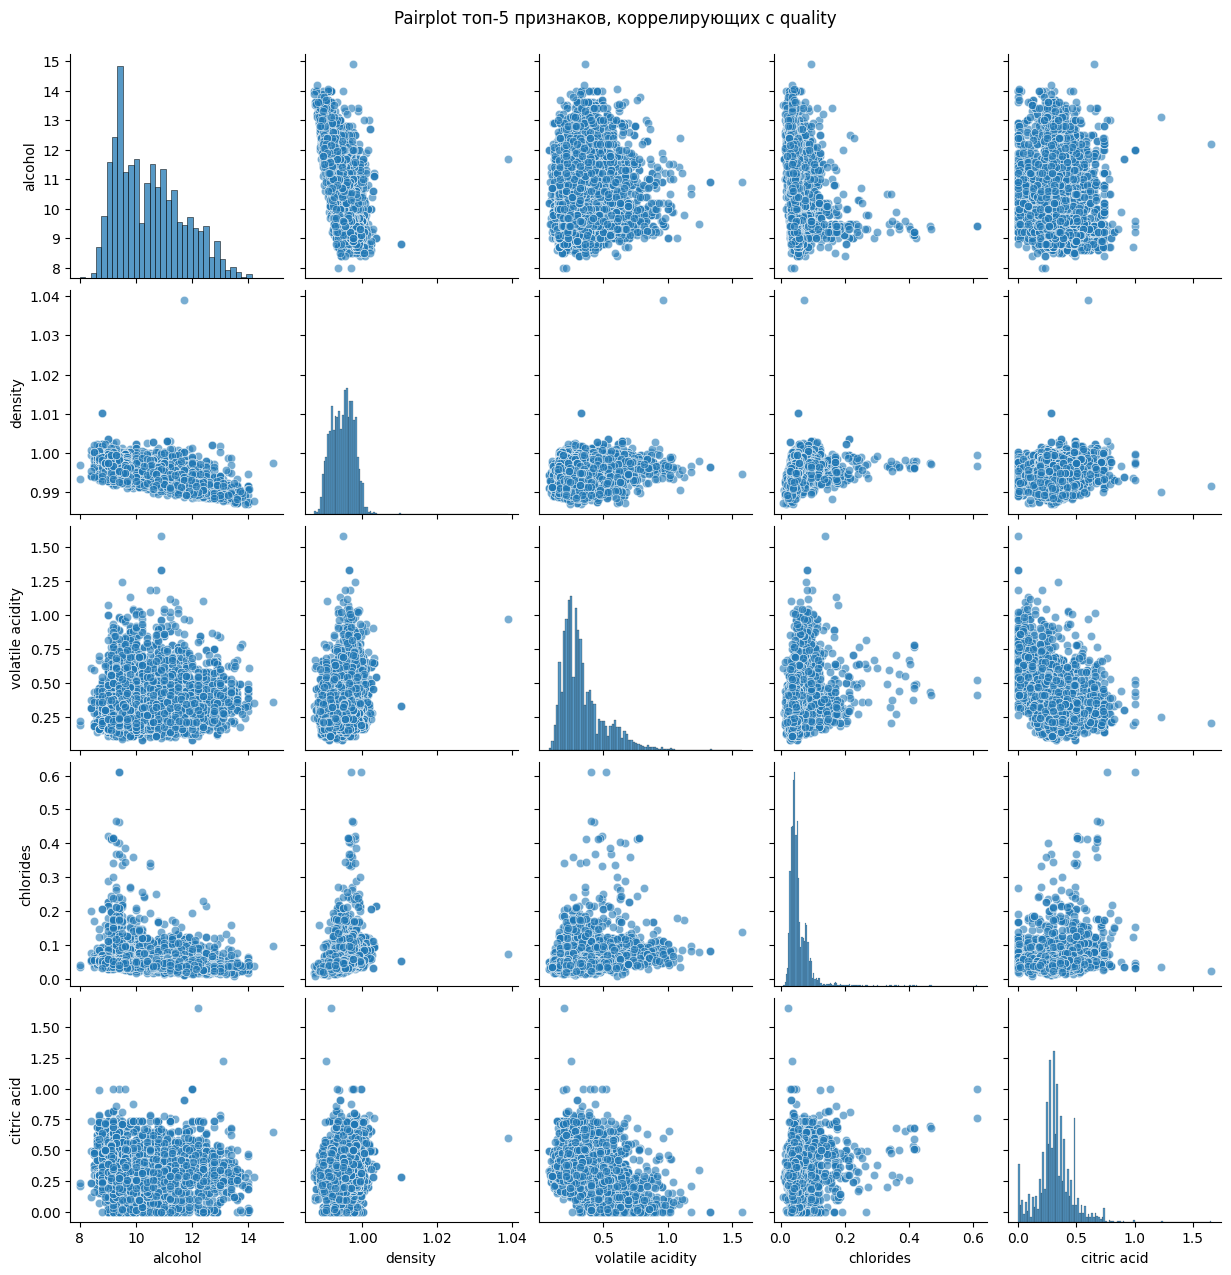

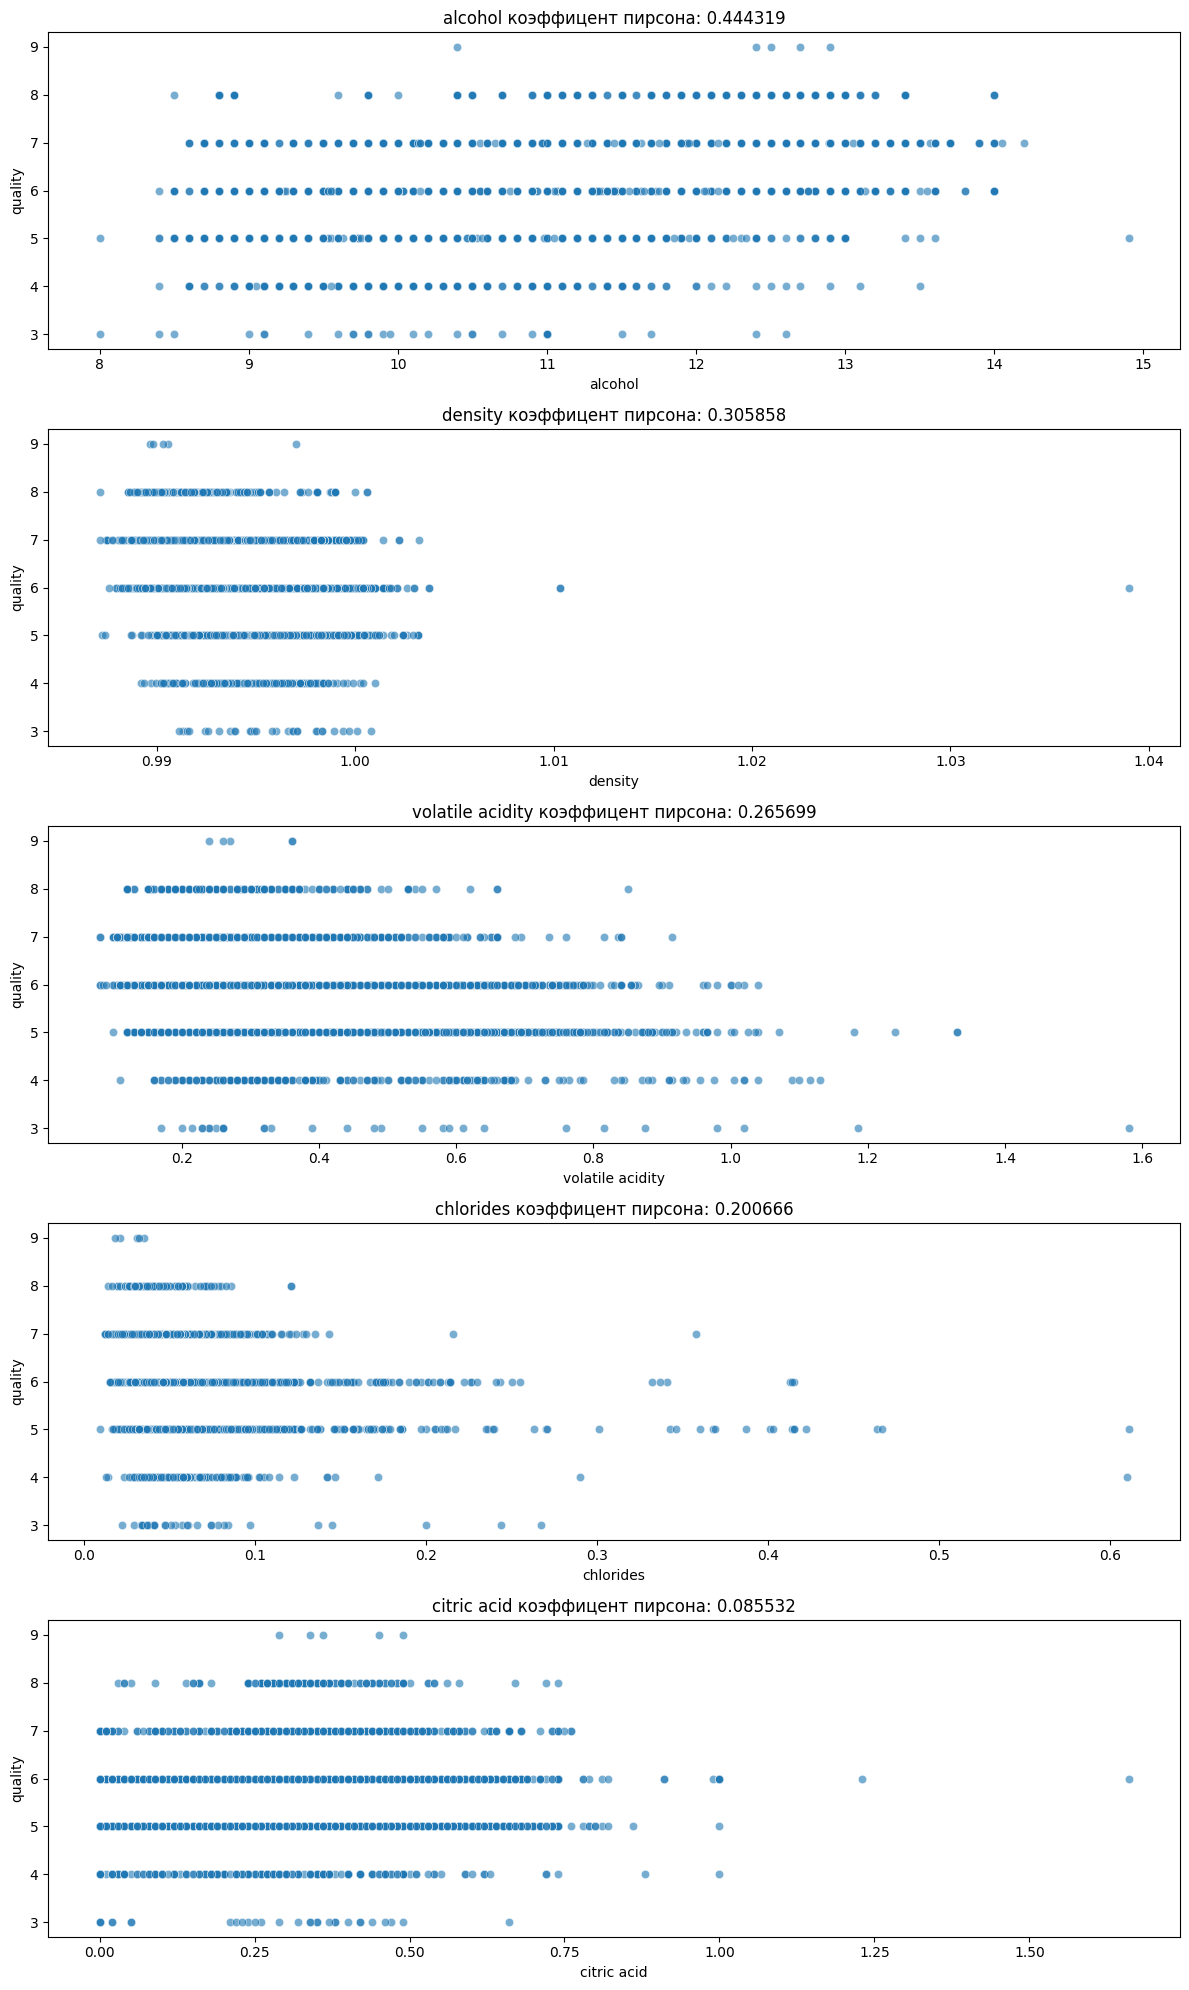

In [55]:
# your code here
pearson_quality = pearson_corr['quality'].drop('quality').abs().sort_values(ascending=False)
top5_pearson = pearson_quality.head(5).index.tolist()

print("Топ-5 признаков по корреляции Пирсона с quality:", top5_pearson)
sns.pairplot(rw_data[top5_pearson], diag_kind='hist', plot_kws={'alpha':0.6})
plt.suptitle('Pairplot топ-5 признаков, коррелирующих с quality', y=1.02)
plt.show()

ig, axes = plt.subplots(5, 1, figsize=(12, 4*5))
axes = axes.flatten()
for i, col in enumerate(top5_pearson):
    sns.scatterplot(x=col, y='quality', data=rw_data, alpha=0.6, ax=axes[i])
    axes[i].set_title(f'{col} коэффицент пирсона: {pearson_quality[col]:2f}')


plt.tight_layout()
plt.show()

### Задание 5. Линейная регрессия (2 балла)

1. Простая регрессия – выберите признак с максимальной (по модулю) корреляцией Пирсона с `quality`.

    - Обучите `LinearRegression` на 80% данных, обязательно фиксируйте `random_state`.
    - Выведите R^2 и MSE на тестовой выборке.

2. Множественная регрессия на всех числовых признаках (кроме `quality`).
    - Обучите модель, выведите R^2 и MSE.

3. Отберите вручную не более 3-5 признаков с учетом информации из задания 3.
    - Заново обучите множественную регрессию на оставшихся признаках и выведите R^2, MSE.
    - Обоснуйте свой выбор.

4. Сравните три модели (простая, множественная на всех, множественная после удаления VIF). Какая лучше и почему?

In [ ]:
# your code here
alcohol = rw_data[top5_pearson[0]]
y = rw_data["quality"].array
x = alcohol.array
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Обучение и предсказание
model_single = LinearRegression()
model_single.fit(X_train.reshape(-1,1), y_train)
y_pred_single = model_single.predict(X_test.reshape(-1,1))

# Метрики
r2_single = r2_score(y_test, y_pred_single)
mse_single = mean_squared_error(y_test, y_pred_single)
print(f"Простая регрессия (признак: {top5_pearson[0]})")
print(f"R^2 = {r2_single:.4f}, MSE = {mse_single:.4f}\n")


feature_cols = [col for col in numeric_cols if col != 'quality']
X_all = rw_data[feature_cols]

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

model_all = LinearRegression()
model_all.fit(X_train_all, y_train)
y_pred_all = model_all.predict(X_test_all)

r2_all = r2_score(y_test, y_pred_all)
mse_all = mean_squared_error(y_test, y_pred_all)
print(f"Множественная регрессия (все признаки)")
print(f"R^2 = {r2_all:.4f}, MSE = {mse_all:.4f}\n")


feature_cols = top5_pearson
X_ = rw_data[feature_cols]

X_train_, X_test_, y_train, y_test = train_test_split(
    X_, y, test_size=0.2, random_state=42
)

model_ = LinearRegression()
model_.fit(X_train_, y_train)
y_pred_ = model_.predict(X_test_)

r2_ = r2_score(y_test, y_pred_)
mse_ = mean_squared_error(y_test, y_pred_)
print(f"Множественная регрессия (выбранные признаки)")
print(f"R^2 = {r2_:.4f}, MSE = {mse_:.4f}\n")

Простая регрессия (признак: alcohol)
R^2 = 0.1816, MSE = 0.6044

Множественная регрессия (все признаки)
R^2 = 0.2598, MSE = 0.5467

Множественная регрессия (все признаки)
R^2 = 0.2526, MSE = 0.5520



### Задание 6. Линейная регрессия statsmodels (2 балла)

1. Используя те же признаки, что и в финальной модели задания 5, обучите линейную регрессию через statsmodels.OLS. Добавьте константу (sm.add_constant). Выведите .summary().

Проанализируйте:
- p-value для каждого признака – какие признаки статистически значимы (p < 0.05)?
- R-squared и Adj. R-squared – насколько они отличаются?
- F-статистику и её p-value – значима ли модель в целом?
- Сравните результаты с моделью из sklearn – одинаковы ли коэффициенты и метрики?

In [ ]:
# your code here
X_train_const = sm.add_constant(X_train_)
X_sm_train = sm.add_constant(X_train_)
ols_model = sm.OLS(y_train, X_train_const).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     387.5
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        10:55:53   Log-Likelihood:                -5865.4
No. Observations:                5197   AIC:                         1.174e+04
Df Residuals:                    5191   BIC:                         1.178e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -42.1487      5.329  